# Random Forest

Post-binning contig correctness prediction on the bundled SPAdes example data.

This notebook reads `tests/data/initial_contig_bins.csv` as the initial binner output. The target is `1` for an incorrect initial bin assignment and `0` for a correct assignment among binned contigs.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
try:
    import seaborn as sns
except ImportError:
    sns = None

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists() and (candidate / "tests" / "data").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / "src"))

from binfailgraph.features import build_feature_table
from binfailgraph.labels import make_contig_labels, summarize_labels, task_frame
from binfailgraph.modeling import (
    COMPARISON_FEATURE_SETS,
    compare_feature_sets,
    plot_feature_set_roc_curves,
    select_feature_columns,
)

if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")
DATASET = "Sim-5G"
DATA = ROOT / "tests" / "data" / DATASET
INITIAL_BINS = DATA / "initial_contig_bins.csv"
INCLUDE_KMERS = True
TASK = "misbin"

## Data and Labels

In [2]:
raw_features = build_feature_table(
    graph_file=DATA / "assembly_graph_with_scaffolds.gfa",
    contigs_file=DATA / "contigs.fasta",
    contig_paths_file=DATA / "contigs.paths",
    ground_truth_file=DATA / "ground_truth.csv",
    bin_assignments_file=INITIAL_BINS,
    include_kmers=INCLUDE_KMERS,
)

labelled = make_contig_labels(raw_features)
task = task_frame(labelled, task=TASK)

print(f"Contigs in graph: {len(raw_features):,}")
print(f"Initial binned contigs: {raw_features['bin'].notna().sum():,}")
print(f"Rows in {TASK!r} task: {len(task):,}")
print("Target convention: 1 = incorrect initial bin assignment, 0 = correct initial bin assignment")
display(summarize_labels(labelled).to_frame("count"))

Contigs in graph: 519
Initial binned contigs: 209
Rows in 'misbin' task: 206
Target convention: 1 = incorrect initial bin assignment, 0 = correct initial bin assignment


,count
is_known_truth,509
is_binned,209
correctly_binned,192
mis_binned,14
unbinned_should_bin,303
in_contaminated_bin,0
label_failure,317


## Model

In [3]:
from binfailgraph.modeling import make_random_forest

MODEL_NAME = "Random Forest"
def MODEL_FACTORY():
    return make_random_forest(random_state=42)

## Feature-Set Comparison

The same model is evaluated with five feature sets: length only, coverage only, composition + coverage, graph only, and composition + coverage + graph. Performance is reported with AUROC and AUPRC.

In [4]:
comparison_table, comparison_results = compare_feature_sets(
    task,
    model_factory=MODEL_FACTORY,
    feature_sets=COMPARISON_FEATURE_SETS,
    target_col="target",
    test_size=0.30,
    random_state=42,
    top_k_fraction=0.10,
)

display(
    comparison_table[
        ["feature_set_label", "n_features", "auroc", "auprc"]
    ].style.format({"auroc": "{:.3f}", "auprc": "{:.3f}"})
)

result = comparison_results["composition_coverage_graph"]
feature_columns = select_feature_columns(task, feature_set="composition_coverage_graph")
print(f"Using {len(feature_columns):,} composition + coverage + graph features for diagnostics below.")
display(result.metrics.to_frame("value"))
display(result.test_predictions.head(25))

,feature_set_label,n_features,auroc,auprc
0,Length only,1,0.761,0.254
1,Coverage only,1,0.864,0.590
2,Composition + coverage,138,0.871,0.276
3,Graph only,19,1.000,1.000
4,Composition + coverage + graph,165,0.974,0.799


Using 165 composition + coverage + graph features for diagnostics below.


,value
n_train,144.000000
n_test,62.000000
positive_rate_test,0.064516
f1,0.000000
precision,0.000000
ece_10bin,0.064391
auroc,0.974138
auprc,0.798611
precision_at_top_10pct,0.428571
recall_at_top_10pct,0.750000


,contig,contig_short,target,risk_score
223,NODE_224_length_1722_cov_87.068986,NODE_224,1,0.424884
232,NODE_233_length_1494_cov_95.593468,NODE_233,1,0.422029
213,NODE_214_length_2581_cov_275.389153,NODE_214,0,0.412954
209,NODE_210_length_2707_cov_70.430995,NODE_210,1,0.400872
203,NODE_204_length_3394_cov_549.838874,NODE_204,0,0.361114
250,NODE_251_length_1032_cov_313.062436,NODE_251,0,0.278655
229,NODE_230_length_1519_cov_184.546448,NODE_230,0,0.248733
221,NODE_222_length_1849_cov_680.093088,NODE_222,0,0.199392
169,NODE_170_length_8681_cov_118.314630,NODE_170,1,0.187990
235,NODE_236_length_1450_cov_29.849462,NODE_236,0,0.164004


## ROC Curves

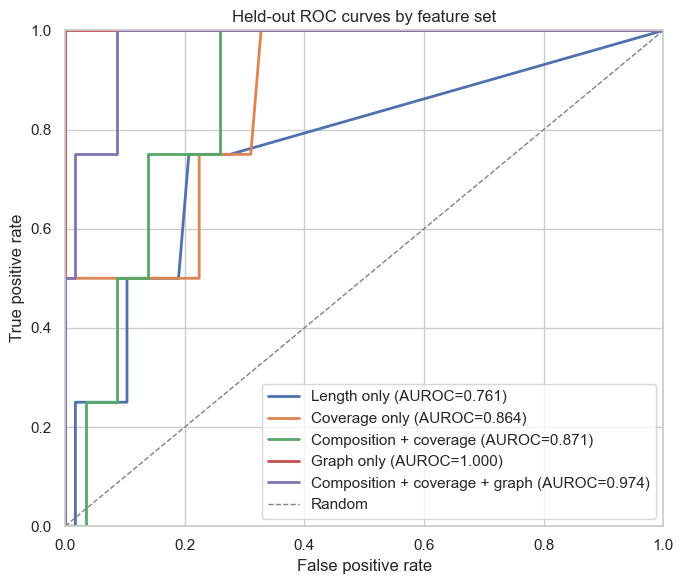

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_feature_set_roc_curves(comparison_results, ax=ax)
plt.tight_layout()
plt.show()

## Full Feature-Set Importance

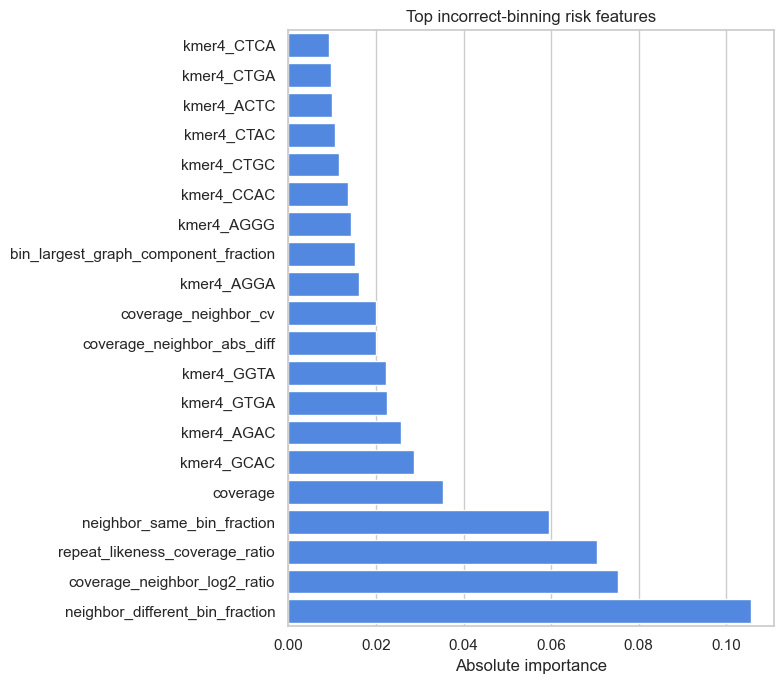

In [6]:
top = result.feature_importance.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
if sns is not None:
    sns.barplot(data=top, x="abs_importance", y="feature", ax=ax, color="#3b82f6")
else:
    ax.barh(top["feature"], top["abs_importance"], color="#3b82f6")
ax.set_xlabel("Absolute importance")
ax.set_ylabel("")
ax.set_title("Top incorrect-binning risk features")
plt.tight_layout()
plt.show()